In [32]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
from sklearn.impute import KNNImputer

In [15]:
data, meta = arff.loadarff('../data/bone-marrow.arff')
df = pd.DataFrame(data)

df.head()

,Recipientgender,Stemcellsource,Donorage,Donorage35,IIIV,Gendermatch,DonorABO,RecipientABO,RecipientRh,ABOmatch,...,extcGvHD,CD34kgx10d6,CD3dCD34,CD3dkgx10d8,Rbodymass,ANCrecovery,PLTrecovery,time_to_aGvHD_III_IV,survival_time,survival_status
0,b'1',b'1',22.830137,b'0',b'1',b'0',b'1',b'1',b'1',b'0',...,b'1',7.20,1.338760,5.38,35.0,19.0,51.0,32.0,999.0,0.0
1,b'1',b'0',23.342466,b'0',b'1',b'0',b'-1',b'-1',b'1',b'0',...,b'1',4.50,11.078295,0.41,20.6,16.0,37.0,1000000.0,163.0,1.0
2,b'1',b'0',26.394521,b'0',b'1',b'0',b'-1',b'-1',b'1',b'0',...,b'1',7.94,19.013230,0.42,23.4,23.0,20.0,1000000.0,435.0,1.0
3,b'0',b'0',39.684932,b'1',b'1',b'0',b'1',b'2',b'1',b'1',...,b'?',4.25,29.481647,0.14,50.0,23.0,29.0,19.0,53.0,1.0
4,b'0',b'1',33.358904,b'0',b'0',b'0',b'1',b'2',b'0',b'1',...,b'1',51.85,3.972255,13.05,9.0,14.0,14.0,1000000.0,2043.0,0.0


In [26]:
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].apply(lambda x: x.decode() if isinstance(x, bytes) else x)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df.head()

,Recipientgender,Stemcellsource,Donorage,Donorage35,IIIV,Gendermatch,DonorABO,RecipientABO,RecipientRh,ABOmatch,CMVstatus,DonorCMV,RecipientCMV,Disease,Riskgroup,Txpostrelapse,Diseasegroup,HLAmatch,HLAmismatch,Antigen,Alel,HLAgrI,Recipientage,Recipientage10,Recipientageint,Relapse,aGvHDIIIIV,extcGvHD,CD34kgx10d6,CD3dCD34,CD3dkgx10d8,Rbodymass,ANCrecovery,PLTrecovery,time_to_aGvHD_III_IV,survival_time,survival_status
0,1,1,22.830137,0,1,0,1,1,1,0,3,1,1,ALL,1,0,1,0,0,-1,-1,0,9.6,0,1,0,0,1,7.20,1.338760,5.38,35.0,19.0,51.0,32.0,999.0,0.0
1,1,0,23.342466,0,1,0,-1,-1,1,0,0,0,0,ALL,0,0,1,0,0,-1,-1,0,4.0,0,0,1,1,1,4.50,11.078295,0.41,20.6,16.0,37.0,1000000.0,163.0,1.0
2,1,0,26.394521,0,1,0,-1,-1,1,0,2,0,1,ALL,0,0,1,0,0,-1,-1,0,6.6,0,1,1,1,1,7.94,19.013230,0.42,23.4,23.0,20.0,1000000.0,435.0,1.0
3,0,0,39.684932,1,1,0,1,2,1,1,1,1,0,AML,0,0,1,0,0,-1,-1,0,18.1,1,2,0,0,?,4.25,29.481647,0.14,50.0,23.0,29.0,19.0,53.0,1.0
4,0,1,33.358904,0,0,0,1,2,0,1,0,0,1,chronic,1,0,1,1,0,1,0,1,1.3,0,0,0,1,1,51.85,3.972255,13.05,9.0,14.0,14.0,1000000.0,2043.0,0.0


In [18]:
df.describe()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Recipientgender       187 non-null    str    
 1   Stemcellsource        187 non-null    str    
 2   Donorage              187 non-null    float64
 3   Donorage35            187 non-null    str    
 4   IIIV                  187 non-null    str    
 5   Gendermatch           187 non-null    str    
 6   DonorABO              187 non-null    str    
 7   RecipientABO          187 non-null    str    
 8   RecipientRh           187 non-null    str    
 9   ABOmatch              187 non-null    str    
 10  CMVstatus             187 non-null    str    
 11  DonorCMV              187 non-null    str    
 12  RecipientCMV          187 non-null    str    
 13  Disease               187 non-null    str    
 14  Riskgroup             187 non-null    str    
 15  Txpostrelapse         187 non-null

In [19]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 187
Number of columns: 37


In [27]:
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].apply(lambda x: x.decode() if isinstance(x, bytes) else x)

# Puis remplacer les '?' par NaN
df.replace('?', np.nan, inplace=True)

,Recipientgender,Stemcellsource,Donorage,Donorage35,IIIV,Gendermatch,DonorABO,RecipientABO,RecipientRh,ABOmatch,CMVstatus,DonorCMV,RecipientCMV,Disease,Riskgroup,Txpostrelapse,Diseasegroup,HLAmatch,HLAmismatch,Antigen,Alel,HLAgrI,Recipientage,Recipientage10,Recipientageint,Relapse,aGvHDIIIIV,extcGvHD,CD34kgx10d6,CD3dCD34,CD3dkgx10d8,Rbodymass,ANCrecovery,PLTrecovery,time_to_aGvHD_III_IV,survival_time,survival_status
0,1,1,22.830137,0,1,0,1,1,1,0,3,1,1,ALL,1,0,1,0,0,-1,-1,0,9.6,0,1,0,0,1,7.200,1.338760,5.38,35.00,19.0,51.0,32.0,999.0,0.0
1,1,0,23.342466,0,1,0,-1,-1,1,0,0,0,0,ALL,0,0,1,0,0,-1,-1,0,4.0,0,0,1,1,1,4.500,11.078295,0.41,20.60,16.0,37.0,1000000.0,163.0,1.0
2,1,0,26.394521,0,1,0,-1,-1,1,0,2,0,1,ALL,0,0,1,0,0,-1,-1,0,6.6,0,1,1,1,1,7.940,19.013230,0.42,23.40,23.0,20.0,1000000.0,435.0,1.0
3,0,0,39.684932,1,1,0,1,2,1,1,1,1,0,AML,0,0,1,0,0,-1,-1,0,18.1,1,2,0,0,NaN,4.250,29.481647,0.14,50.00,23.0,29.0,19.0,53.0,1.0
4,0,1,33.358904,0,0,0,1,2,0,1,0,0,1,chronic,1,0,1,1,0,1,0,1,1.3,0,0,0,1,1,51.850,3.972255,13.05,9.00,14.0,14.0,1000000.0,2043.0,0.0
5,1,0,27.391781,0,0,0,2,0,1,1,NaN,NaN,1,chronic,1,1,1,0,0,-1,-1,0,8.9,0,1,0,1,1,3.270,8.412758,0.39,40.00,16.0,70.0,1000000.0,2800.0,0.0
6,0,1,34.520548,0,1,0,0,1,0,1,NaN,0,NaN,AML,0,0,1,0,0,-1,-1,0,14.4,1,2,0,0,NaN,17.780,2.406248,7.39,51.00,17.0,29.0,18.0,41.0,1.0
7,1,0,21.435616,0,1,0,0,1,1,1,1,1,0,nonmalignant,0,0,0,3,1,1,2,7,18.2,1,2,0,0,NaN,6.410,NaN,NaN,56.00,22.0,58.0,22.0,45.0,1.0
8,1,1,32.641096,0,0,0,2,0,1,1,2,0,1,nonmalignant,0,0,0,0,0,-1,-1,0,7.9,0,1,0,1,1,23.540,3.772555,6.24,20.50,15.0,14.0,1000000.0,671.0,0.0
9,1,1,28.783562,0,1,1,1,0,1,1,2,0,1,nonmalignant,0,0,0,1,0,0,1,3,4.7,0,0,0,1,1,7.690,1.035244,7.43,16.50,16.0,17.0,1000000.0,676.0,0.0


In [38]:
df.isnull().sum()

Recipientgender         0
Stemcellsource          0
Donorage                0
Donorage35              0
IIIV                    0
Gendermatch             0
DonorABO                0
RecipientABO            0
RecipientRh             0
ABOmatch                0
CMVstatus               0
DonorCMV                0
RecipientCMV            0
Disease                 0
Riskgroup               0
Txpostrelapse           0
Diseasegroup            0
HLAmatch                0
HLAmismatch             0
Antigen                 0
Alel                    0
HLAgrI                  0
Recipientage            0
Recipientage10          0
Recipientageint         0
Relapse                 0
aGvHDIIIIV              0
extcGvHD                0
CD34kgx10d6             0
CD3dCD34                0
CD3dkgx10d8             0
Rbodymass               0
ANCrecovery             0
PLTrecovery             0
time_to_aGvHD_III_IV    0
survival_time           0
survival_status         0
dtype: int64

In [35]:
# KNN Imputer sur les colonnes numériques
imputer = KNNImputer(n_neighbors=5)
df[num_cols] = imputer.fit_transform(df[num_cols])

# Mode sur les colonnes catégorielles
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [37]:
df.head()   

,Recipientgender,Stemcellsource,Donorage,Donorage35,IIIV,Gendermatch,DonorABO,RecipientABO,RecipientRh,ABOmatch,CMVstatus,DonorCMV,RecipientCMV,Disease,Riskgroup,Txpostrelapse,Diseasegroup,HLAmatch,HLAmismatch,Antigen,Alel,HLAgrI,Recipientage,Recipientage10,Recipientageint,Relapse,aGvHDIIIIV,extcGvHD,CD34kgx10d6,CD3dCD34,CD3dkgx10d8,Rbodymass,ANCrecovery,PLTrecovery,time_to_aGvHD_III_IV,survival_time,survival_status
0,1,1,22.830137,0,1,0,1,1,1,0,3,1,1,ALL,1,0,1,0,0,-1,-1,0,9.6,0,1,0,0,1,7.20,1.338760,5.38,35.0,19.0,51.0,32.0,999.0,0.0
1,1,0,23.342466,0,1,0,-1,-1,1,0,0,0,0,ALL,0,0,1,0,0,-1,-1,0,4.0,0,0,1,1,1,4.50,11.078295,0.41,20.6,16.0,37.0,1000000.0,163.0,1.0
2,1,0,26.394521,0,1,0,-1,-1,1,0,2,0,1,ALL,0,0,1,0,0,-1,-1,0,6.6,0,1,1,1,1,7.94,19.013230,0.42,23.4,23.0,20.0,1000000.0,435.0,1.0
3,0,0,39.684932,1,1,0,1,2,1,1,1,1,0,AML,0,0,1,0,0,-1,-1,0,18.1,1,2,0,0,1,4.25,29.481647,0.14,50.0,23.0,29.0,19.0,53.0,1.0
4,0,1,33.358904,0,0,0,1,2,0,1,0,0,1,chronic,1,0,1,1,0,1,0,1,1.3,0,0,0,1,1,51.85,3.972255,13.05,9.0,14.0,14.0,1000000.0,2043.0,0.0


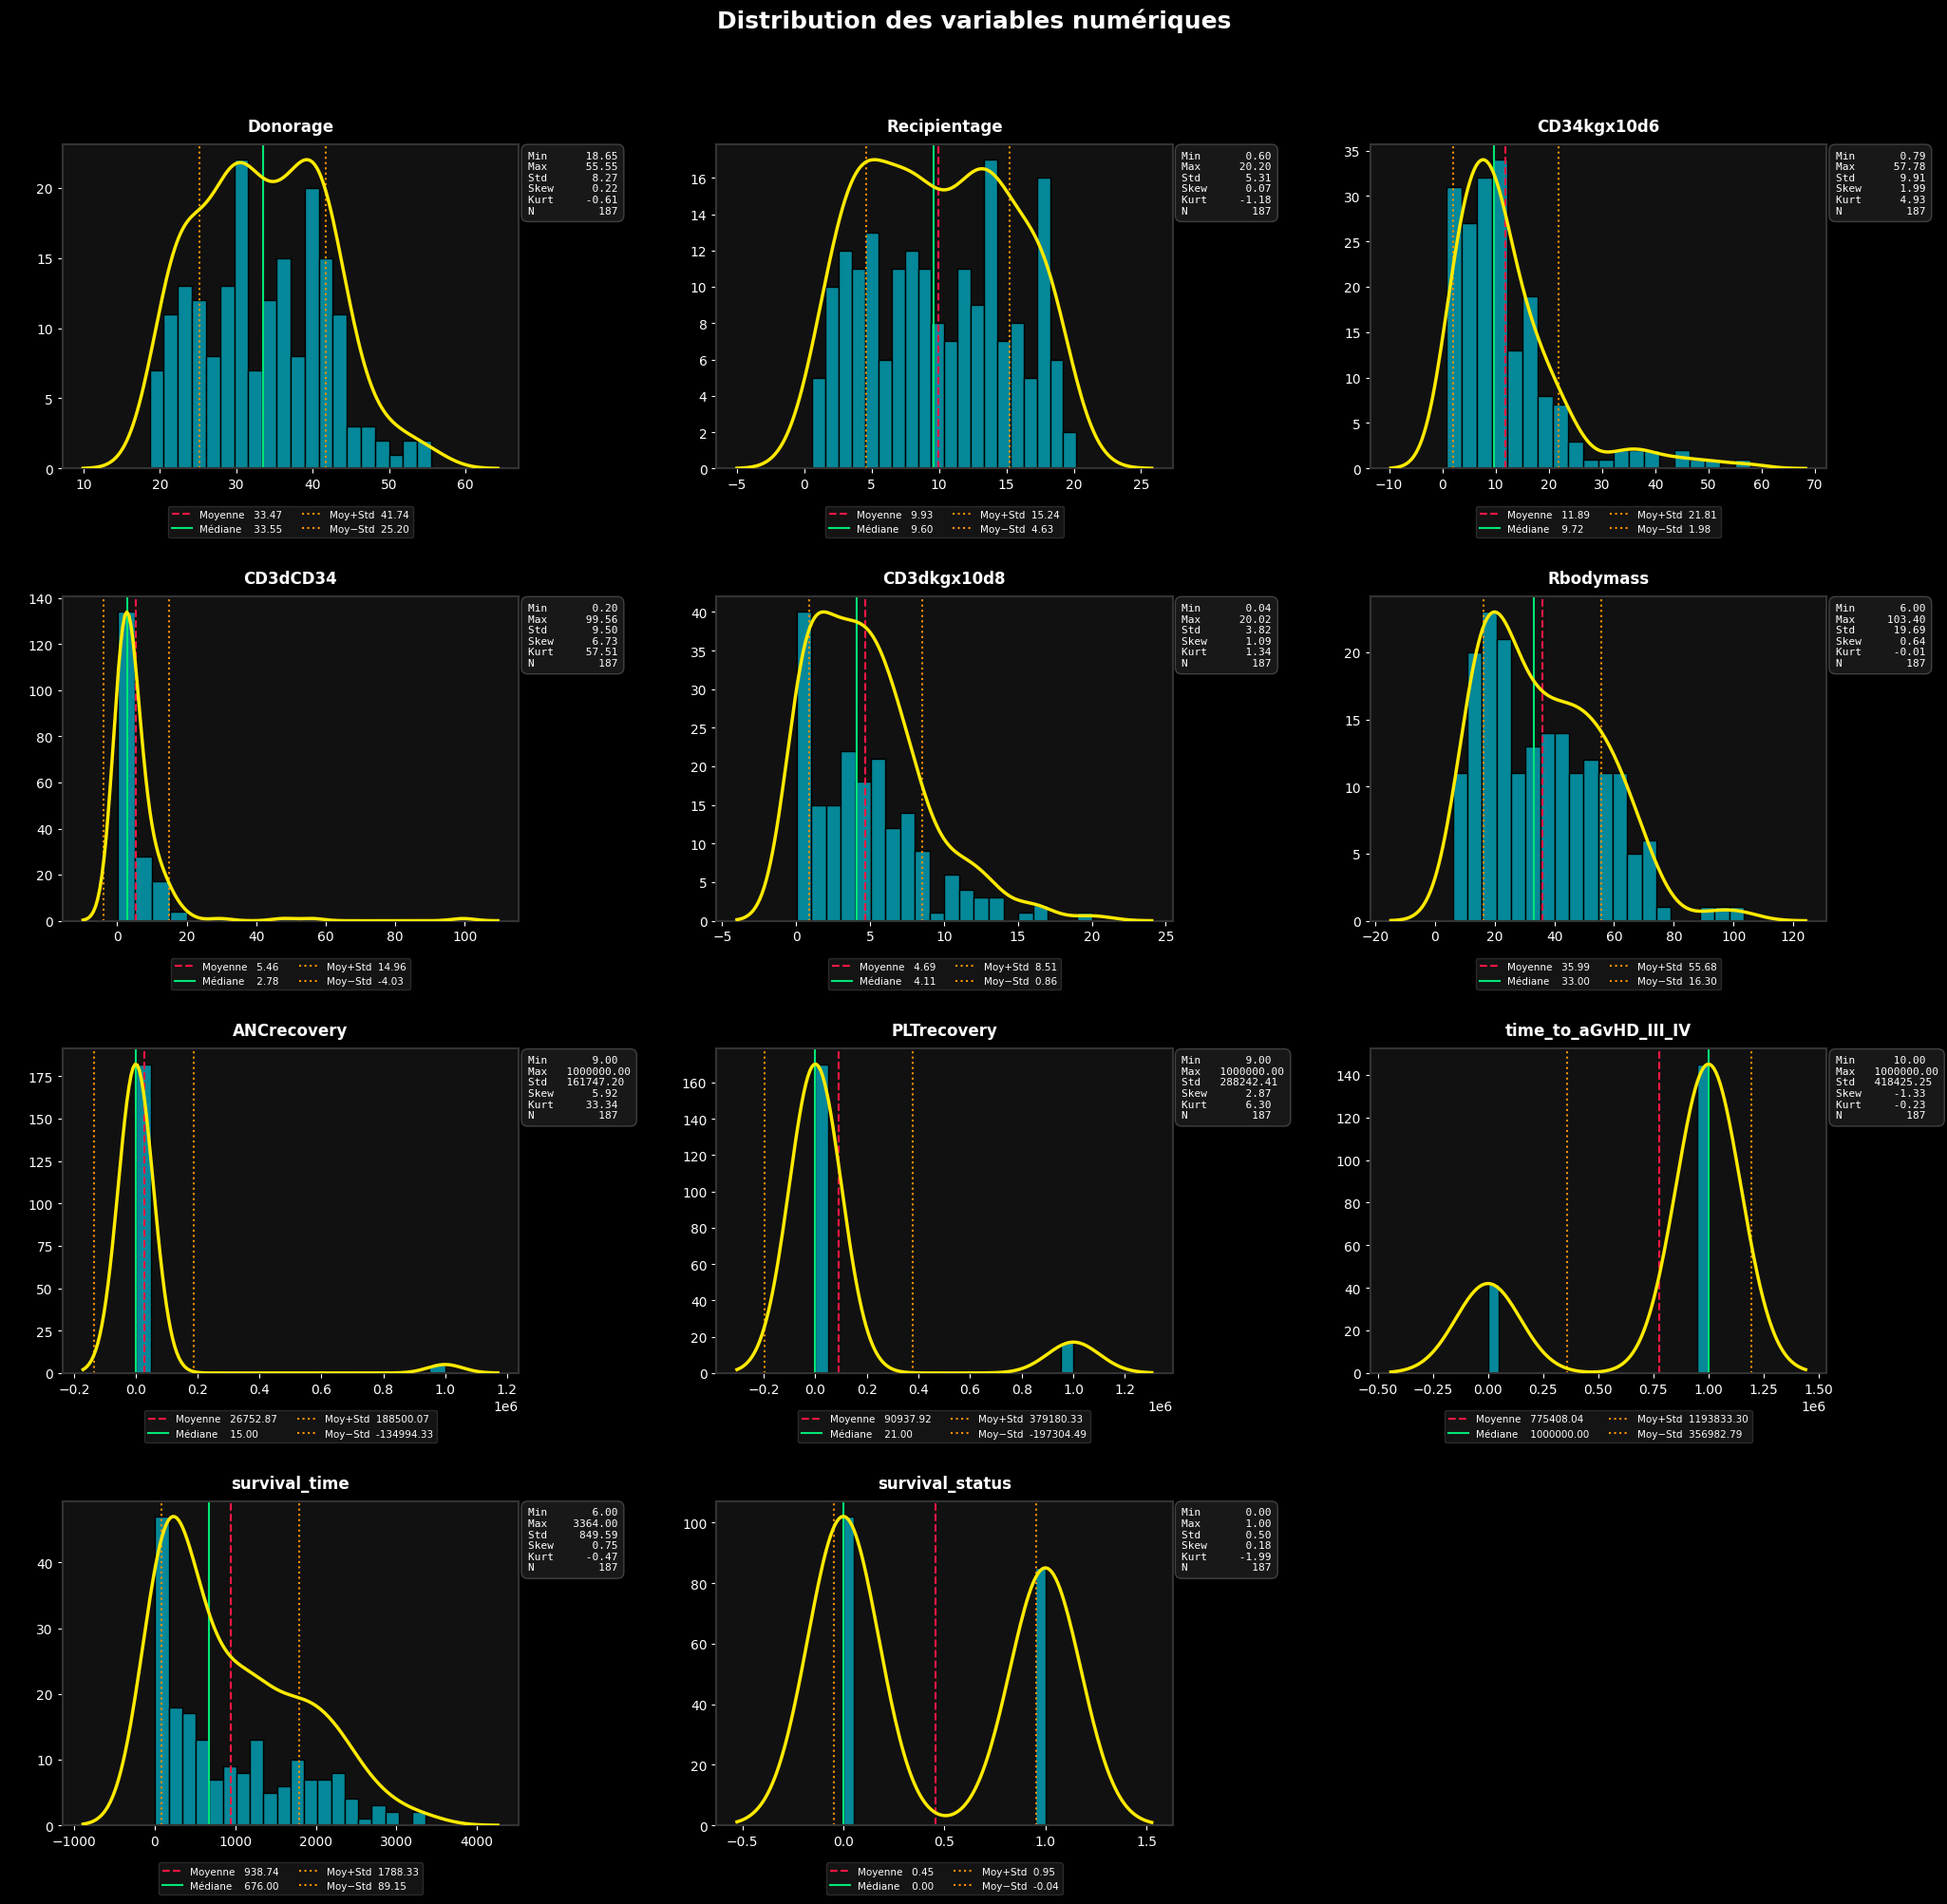

In [64]:
import math

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols,
                         figsize=(n_cols*7, n_rows*5))
fig.patch.set_facecolor('#000000')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.set_facecolor('#111111')

    # Histogramme
    sns.histplot(df[col], bins=20, kde=False, ax=ax,
                 color='#00BCD4', edgecolor='#000000', alpha=0.7)

    # Courbe KDE jaune
    ax2 = ax.twinx()
    sns.kdeplot(df[col], ax=ax2, color='#FFEA00', linewidth=2.5)
    ax2.set_ylabel('')
    ax2.set_yticks([])
    ax2.tick_params(right=False)
    for spine in ax2.spines.values():
        spine.set_visible(False)

    # Lignes statistiques
    ax.axvline(df[col].mean(),
               color='#FF1744', linestyle='--', linewidth=1.5,
               label=f'Moyenne   {df[col].mean():.2f}')
    ax.axvline(df[col].median(),
               color='#00E676', linestyle='-', linewidth=1.5,
               label=f'Médiane    {df[col].median():.2f}')
    ax.axvline(df[col].mean() + df[col].std(),
               color='#FF9100', linestyle=':', linewidth=1.5,
               label=f'Moy+Std  {df[col].mean() + df[col].std():.2f}')
    ax.axvline(df[col].mean() - df[col].std(),
               color='#FF9100', linestyle=':', linewidth=1.5,
               label=f'Moy−Std  {df[col].mean() - df[col].std():.2f}')

    # Boîte de stats à DROITE en dehors des axes
    stats_lines = [
        ('Min',  f'{df[col].min():.2f}'),
        ('Max',  f'{df[col].max():.2f}'),
        ('Std',  f'{df[col].std():.2f}'),
        ('Skew', f'{df[col].skew():.2f}'),
        ('Kurt', f'{df[col].kurt():.2f}'),
        ('N',    f'{df[col].count()}'),
    ]
    stats_text = '\n'.join(f'{k:<5} {v:>8}' for k, v in stats_lines)

    ax.text(1.02, 0.98, stats_text,
            transform=ax.transAxes,
            fontsize=8,
            verticalalignment='top',
            horizontalalignment='left',
            fontfamily='monospace',
            color='#FFFFFF',
            clip_on=False,                    # Permet d'écrire hors des axes
            bbox=dict(boxstyle='round,pad=0.6',
                      facecolor='#1a1a1a',
                      edgecolor='#444444',
                      alpha=0.95))

    # Titre
    ax.set_title(col, fontsize=12, fontweight='bold', color='white', pad=10)
    ax.set_xlabel('')
    ax.grid(False)

    # Légende sous le graphique
    ax.legend(fontsize=7.5,
              frameon=True,
              facecolor='#1a1a1a',
              edgecolor='#333333',
              labelcolor='white',
              loc='upper center',
              bbox_to_anchor=(0.5, -0.10),
              ncol=2)

    # Encadrement
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')
        spine.set_linewidth(1.5)

    ax.tick_params(colors='white')

# Cacher les subplots vides
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
    axes[j].set_facecolor('#000000')

plt.suptitle("Distribution des variables numériques",
             fontsize=18, fontweight='bold', color='white', y=1.01)
plt.tight_layout(pad=2.5)
plt.show()

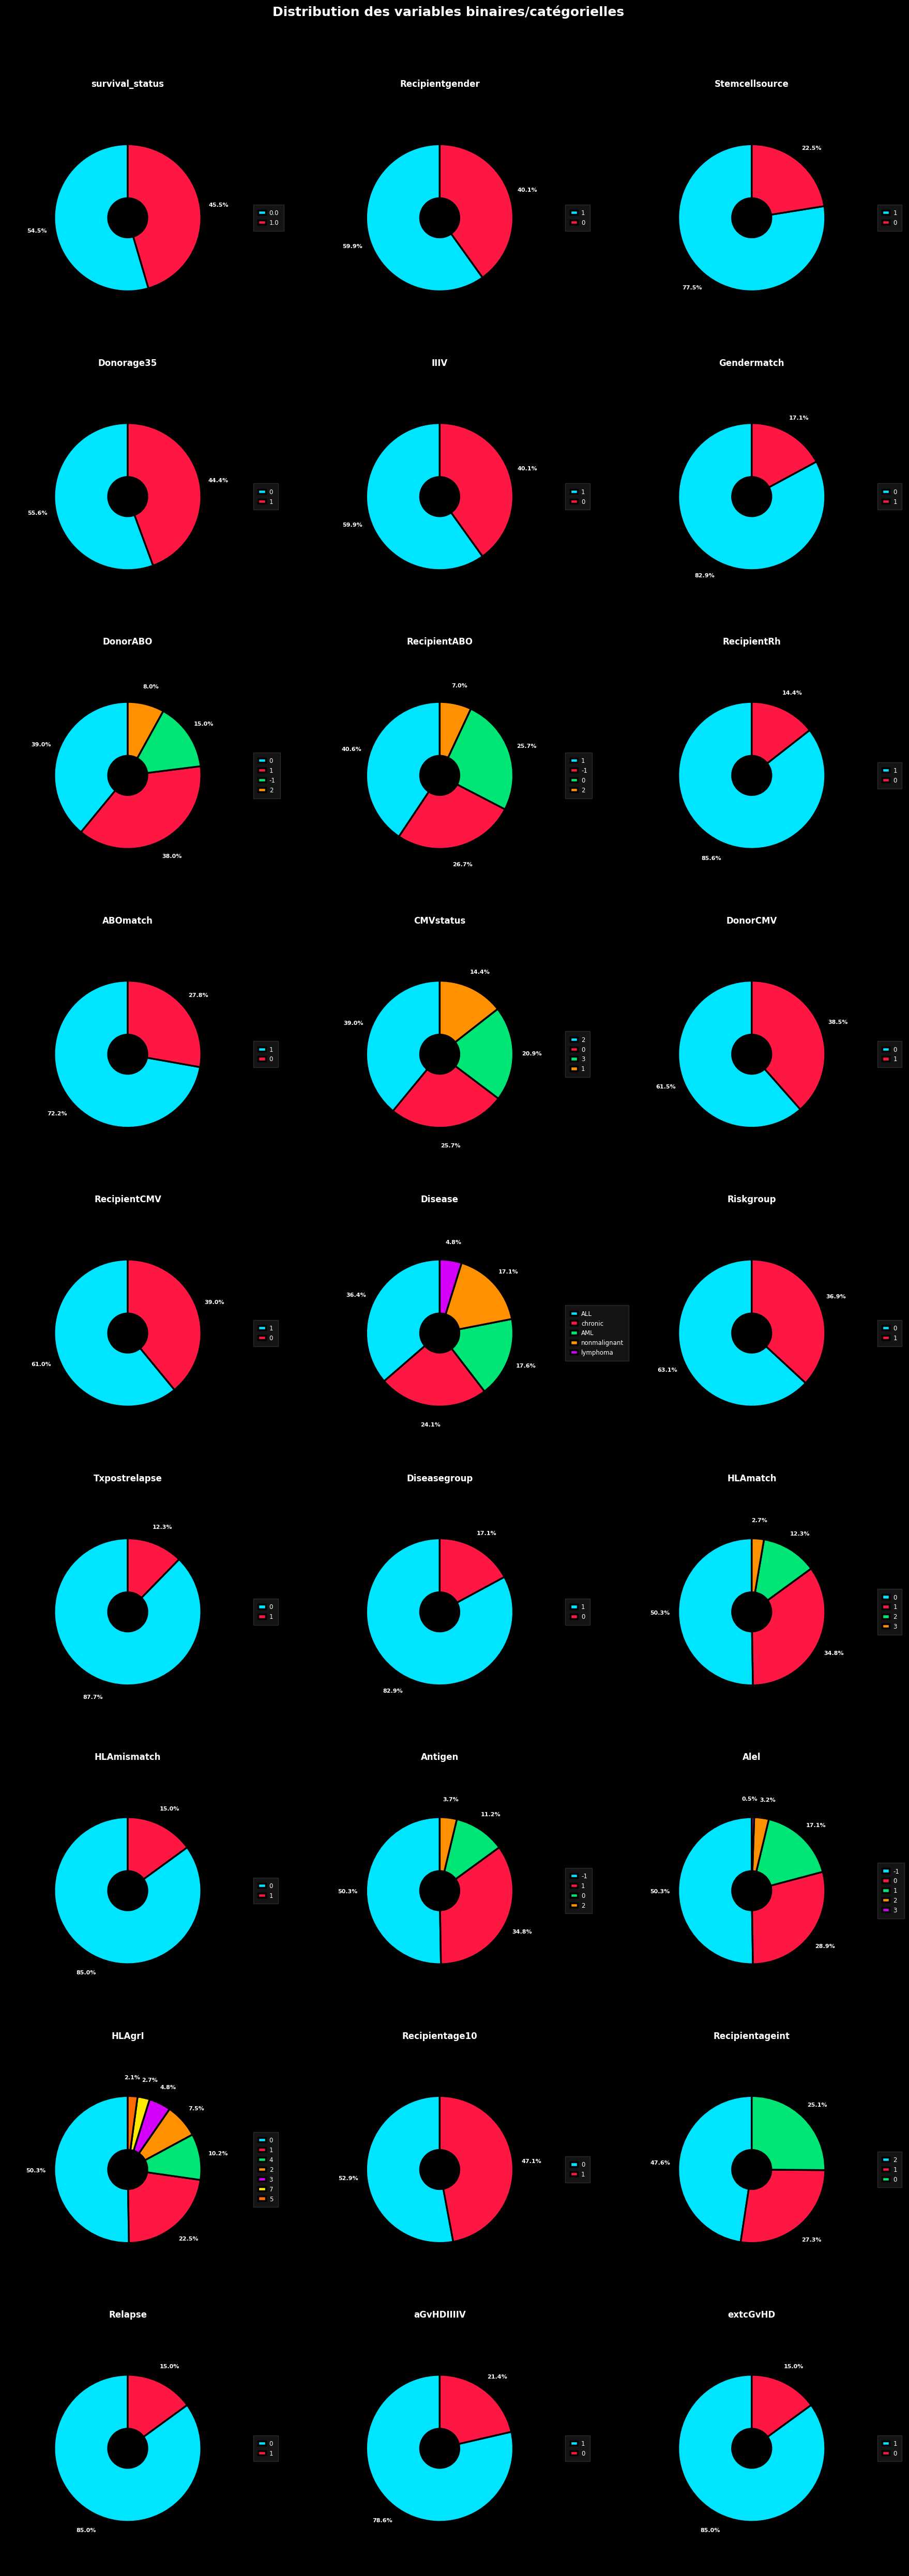

In [65]:
import numpy as np

all_cols = binary_cols + cat_cols_list
n_cols = 3
n_rows = math.ceil(len(all_cols) / n_cols)

palette = ['#00E5FF', '#FF1744', '#00E676', '#FF9100',
           '#D500F9', '#FFEA00', '#FF6D00', '#2979FF',
           '#F50057', '#76FF03']

def fix_label_overlaps(autotexts, min_dist=0.12):
    """Écarte les labels qui se chevauchent"""
    positions = [(a.get_position()[0], a.get_position()[1]) for a in autotexts]
    for _ in range(50):  # Itérations pour converger
        for i in range(len(positions)):
            for j in range(i+1, len(positions)):
                dx = positions[i][0] - positions[j][0]
                dy = positions[i][1] - positions[j][1]
                dist = math.sqrt(dx**2 + dy**2)
                if dist < min_dist and dist > 0:
                    push = (min_dist - dist) / 2
                    nx, ny = dx/dist * push, dy/dist * push
                    positions[i] = (positions[i][0] + nx, positions[i][1] + ny)
                    positions[j] = (positions[j][0] - nx, positions[j][1] - ny)
    for a, (x, y) in zip(autotexts, positions):
        a.set_position((x, y))

fig = plt.figure(figsize=(n_cols * 6, n_rows * 5.5))
fig.patch.set_facecolor('#000000')

for i, col in enumerate(all_cols):
    ax = fig.add_subplot(n_rows, n_cols, i + 1)
    ax.set_facecolor('#111111')

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('#333333')
        spine.set_linewidth(1.5)

    counts = df[col].value_counts().head(8)
    colors_used = palette[:len(counts)]

    wedges, texts, autotexts = ax.pie(
        counts.values,
        autopct='%1.1f%%',
        colors=colors_used,
        startangle=90,
        pctdistance=1.25,
        labeldistance=None,
        wedgeprops=dict(edgecolor='#000000', linewidth=2.5, width=0.55),
        radius=0.75
    )

    for autotext in autotexts:
        autotext.set_color('#FFFFFF')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(8)
        autotext.set_bbox(dict(
            boxstyle='round,pad=0.25',
            facecolor='#000000',
            edgecolor='none',
            alpha=0.6
        ))

    # Corriger les chevauchements
    fix_label_overlaps(autotexts, min_dist=0.18)

    ax.legend(
        wedges,
        [str(label)[:12] for label in counts.index],
        loc='center left',
        bbox_to_anchor=(1.0, 0.5),
        fontsize=8.5,
        frameon=True,
        fancybox=False,
        shadow=False,
        ncol=1,
        labelcolor='white',
        facecolor='#1a1a1a',
        edgecolor='#333333',
        borderpad=0.8,
        handlelength=1.2,
        handletextpad=0.6
    )

    ax.set_title(col, fontsize=12, fontweight='bold',
                 color='white', pad=12)

plt.suptitle("Distribution des variables binaires/catégorielles",
             fontsize=18, fontweight='bold',
             color='white', y=1.01)

plt.tight_layout(pad=2.5)
plt.show()

In [66]:
# ============================================
# DÉTECTION DES OUTLIERS — Méthode IQR
# ============================================
outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({'Colonne': col, 'Q1': Q1, 'Q3': Q3,
                             'IQR': IQR, 'Borne inf': lower,
                             'Borne sup': upper, 'Nb outliers': n_outliers})

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)

                 Colonne              Q1              Q3          IQR  \
0               Donorage       27.039726       40.117809    13.078083   
1           Recipientage        5.050000       14.050000     9.000000   
2            CD34kgx10d6        5.350000       15.415000    10.065000   
3               CD3dCD34        1.809375        6.012993     4.203618   
4            CD3dkgx10d8        1.725000        6.575000     4.850000   
5              Rbodymass       19.250000       50.700000    31.450000   
6            ANCrecovery       13.000000       17.000000     4.000000   
7            PLTrecovery       16.000000       37.000000    21.000000   
8   time_to_aGvHD_III_IV  1000000.000000  1000000.000000     0.000000   
9          survival_time      168.500000     1604.000000  1435.500000   
10       survival_status        0.000000        1.000000     1.000000   

         Borne inf       Borne sup  Nb outliers  
0         7.422602       59.734932            0  
1        -8.450000     

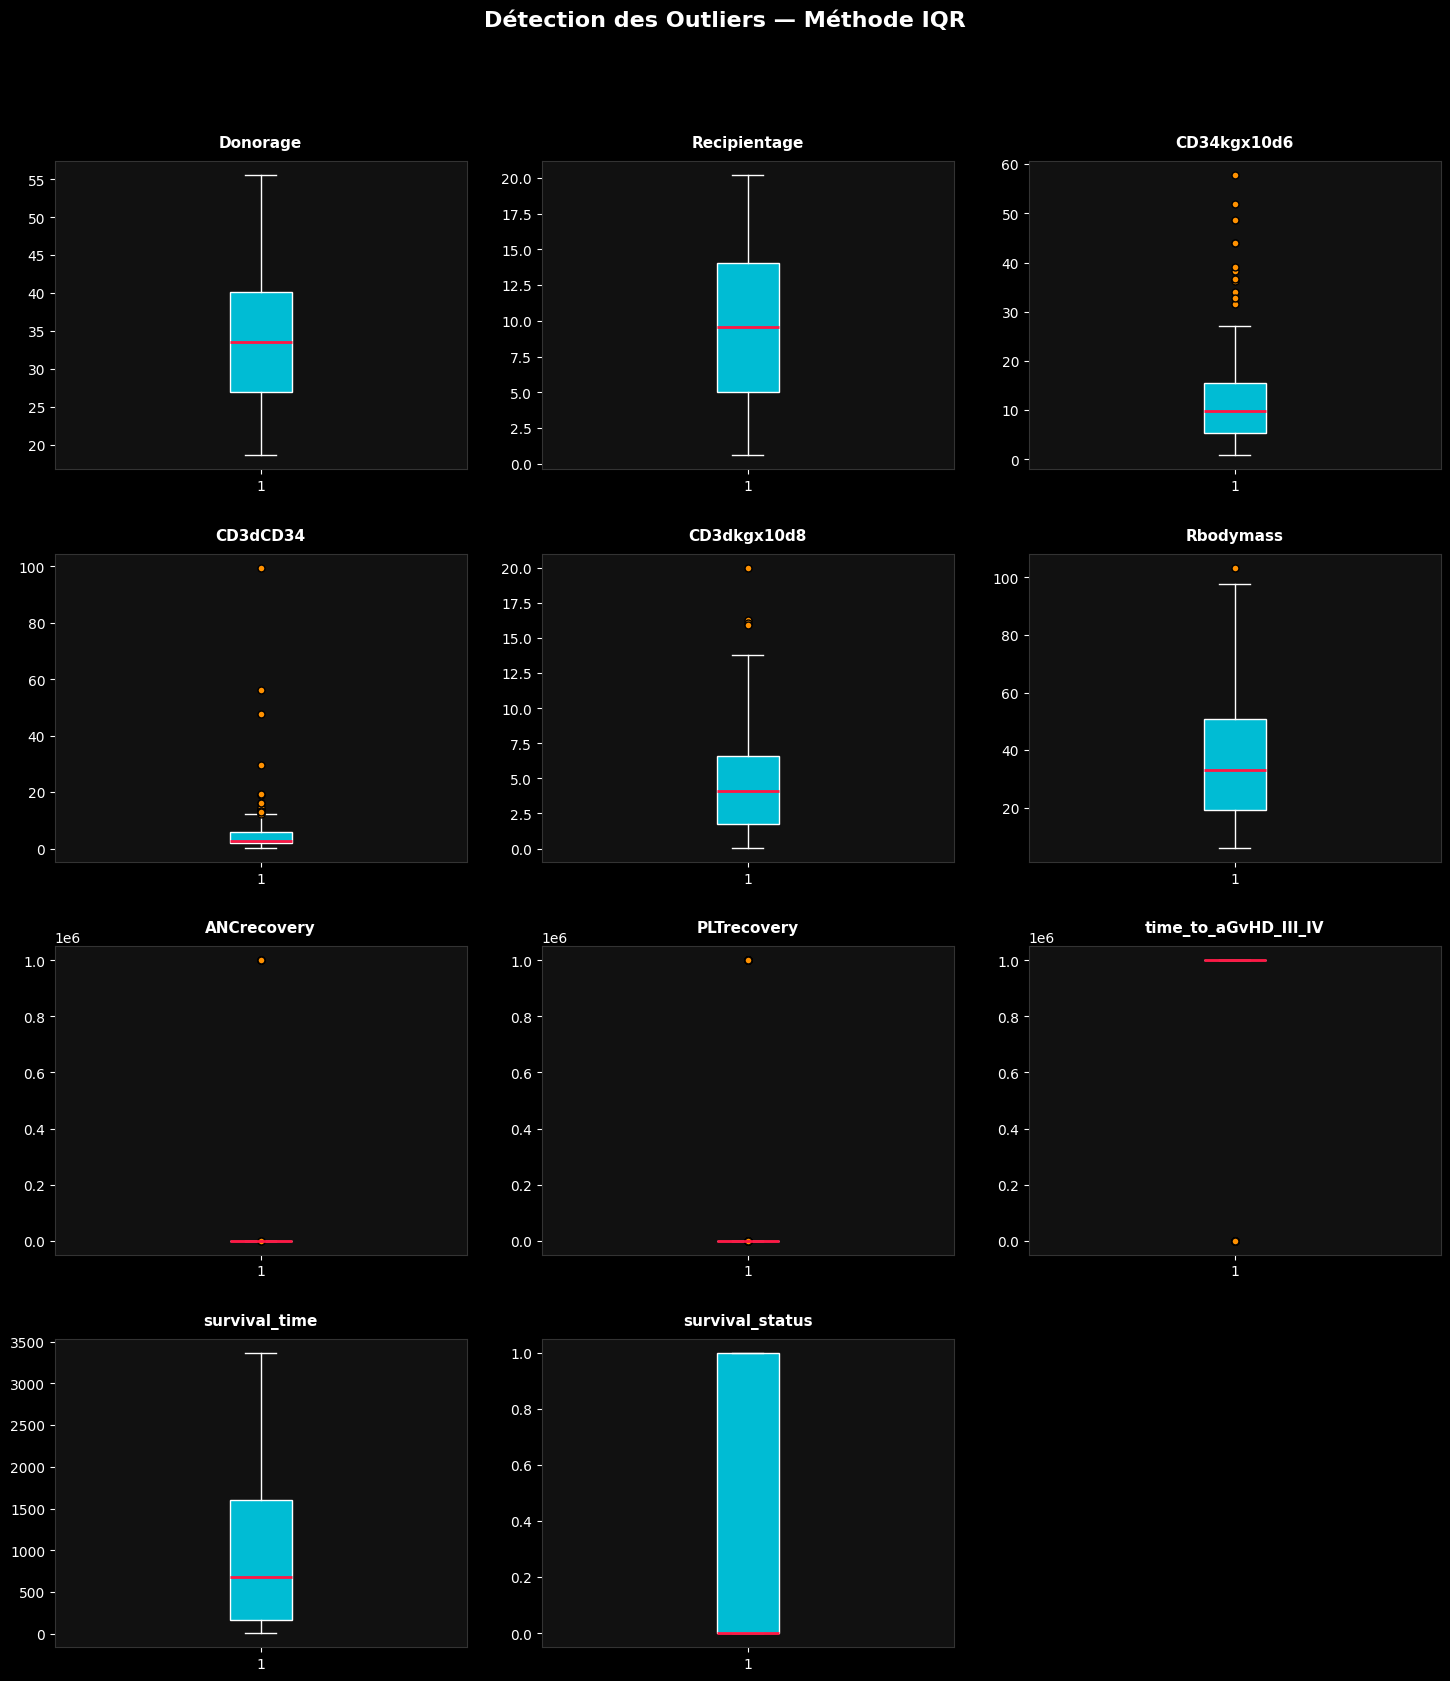

In [67]:
# VISUALISATION — Boxplots
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols*5, n_rows*4))
fig.patch.set_facecolor('#000000')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.set_facecolor('#111111')
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#00BCD4', color='white'),
               medianprops=dict(color='#FF1744', linewidth=2),
               whiskerprops=dict(color='white'),
               capprops=dict(color='white'),
               flierprops=dict(marker='o', color='#FF9100',
                               markerfacecolor='#FF9100', markersize=5))
    ax.set_title(col, fontsize=11, fontweight='bold', color='white', pad=10)
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
    axes[j].set_facecolor('#000000')

plt.suptitle("Détection des Outliers — Méthode IQR",
             fontsize=16, fontweight='bold', color='white', y=1.01)
plt.tight_layout(pad=2.5)
plt.show()

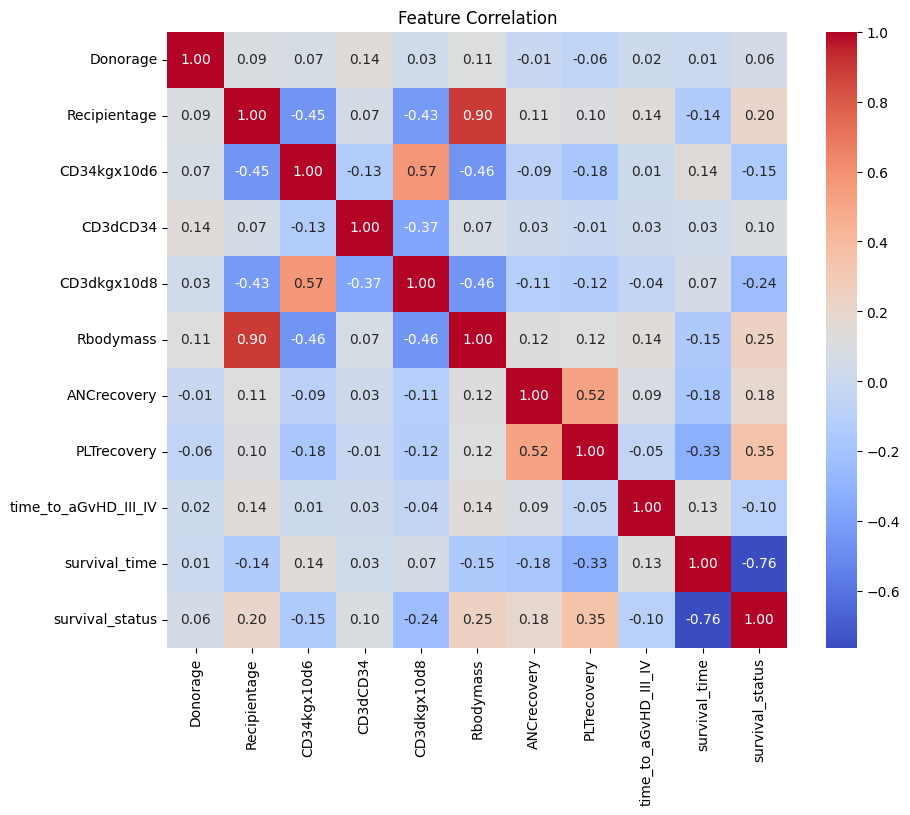

In [40]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', annot=True, fmt='.2f')
plt.title("Feature Correlation")
plt.show()

In [2]:
import sys
print(sys.executable)

c:\Users\user\miniconda3.0\python.exe


In [3]:
!pip install pandas

  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.7 MB 477.8 kB/s eta 0:00:20
   -- ------------------------------------- 0.5/9.7 MB 477.8 kB/s eta 0:00:20
   --- ------------------------------------ 0.8/9.7 MB 482.4 kB/s eta 0:00:19
   --- ------------------------------------ 0.8/9.7 MB 482.4 kB/s eta 0:00:19
   --- ------------------------------------ 0.8/9.7 MB 482.4 kB/s eta 0:00:19
   ---- ----------------------------------- 1.0/9.7 MB 486.5 kB/s eta 0:00:18
   ---- ----------------------------------- 1.0/9.

In [31]:
!pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 329.4 kB/s eta 0:00:23
   -- ------------------------------------- 0.5/8.0 MB 329.4 kB/s eta 0:00:23
   -- ------------------------------------- 0.5/8.0 MB 329.4 kB/s eta 0:00:23
   --- ------------------------------------ 0.8/8.0 MB 324.5 kB/s eta 0:00:23
   --- ------------------------------------ 0.8/8.0 MB 324.5 kB/s eta 0:0

In [5]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 504.7 kB/s eta 0:00:16
   -- ------------------------------------- 0.5/8.1 MB 504.7 kB/s eta 0:00:16
   -- ------------------------------------- 0.5/8.1 MB 504.7 kB/s eta 0:00:16
   --- ------------------------------------ 0.8/8.1 MB 490.8 kB/s eta 0:00:15
   --- ------------------------------------ 0.8/8.1 MB 490.8 kB/s eta 0:00:15
   ----- ---------------------------------- 1.0/8.1 MB 483.1 kB/s eta 0:00:15
   ----- ---------------------------------- 1.0/8.1 MB 48

In [7]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [8]:
!pip install numpy

In [11]:
!pip install scipy

   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/36.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/36.5 MB ? eta -:--:--
    --------------------------------------- 0.5/36.5 MB 529.1 kB/s eta 0:01:09
    --------------------------------------- 0.5/36.5 MB 529.1 kB/s eta 0:01:09
    --------------------------------------- 0.5/36.5 MB 529.1 kB/s eta 0:01:09
    --------------------------------------- 0.8/36.5 MB 493.1 kB/s eta 0:01:13
    --------------------------------------- 0.8/36.5 MB 493.1 kB/s eta 0:01:13
   - -------------------------------------- 1.0/36.5 MB 495.8 kB/s eta 0:01:12
   - -------------------------------------- 1.0/36.5 MB 495.8 kB/s eta 0:01:12
   - -------------------------------------- 1.0/36.5 MB 495.8 kB/s eta 0:01:12
   - -------------